# 3. VLM에게 물어보기: 자율주행, 지금 가도 될까요?



### 3-1. 밑준비

In [ ]:
!pip uninstall -y tokenizers
!pip install tokenizers==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.2 MB/s eta 0:00:00


In [ ]:
import tokenizers
print(tokenizers.__version__)

0.22.2


In [ ]:
# VLM 추론에 필요한 package를 설치합니다.
!pip -q install huggingface_hub accelerate "pillow<12.0"
!pip -q install --no-deps transformers==5.9.0

print("설치가 끝났습니다.")

설치가 끝났습니다.


### 3-2. 모델과 helper 준비

In [ ]:
# local VLM 모델과 processor를 로드합니다.
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

# 다른 VLM으로 바꾸려면 이 한 줄만 교체하세요.
VLM_MODEL = "google/gemma-4-E2B-it"

processor = AutoProcessor.from_pretrained(VLM_MODEL)
# device_map="auto"는 가능한 GPU/CPU 배치를 transformers가 자동으로 정하게 합니다.
model = AutoModelForImageTextToText.from_pretrained(
    VLM_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print("model loaded:", VLM_MODEL)

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

model loaded: google/gemma-4-E2B-it


In [ ]:
import re


# 이미지와 prompt를 모델에 넣고 답변을 생성합니다.
def run_vlm(image_path, prompt, model=model, processor=processor, max_new_tokens=1024, enable_thinking=True):
    image = Image.open(image_path).convert("RGB")
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]
    # chat template은 role/content 메시지를 모델이 학습된 대화 형식의 token 입력으로 바꿉니다.
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    ).to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generated_ids = output_ids[0][input_len:]
    clean = processor.decode(generated_ids, skip_special_tokens=True).strip()
    raw = processor.decode(generated_ids, skip_special_tokens=False).strip()
    return {"clean": clean, "raw": raw}


# 모델 출력에서 <answer>...</answer> 안쪽 값만 꺼냅니다.
# 태그가 없으면 전체 텍스트를 그대로 돌려줘서, 아래 parse_choice가 단어 매칭을 시도할 수 있게 합니다.
def extract_answer_value(text):
    text = str(text).strip()
    match = re.search(r"<answer>\s*(.*?)\s*</answer>", text, flags=re.I | re.S)
    if match:
        return match.group(1).strip()
    return text


# 모델 답에서 보기 문자(A~D)나 보기 단어를 찾아 (문자, 선택지 텍스트)로 정리합니다.
# 간단한 규칙 기반 매칭이므로, 답이 특이한 형식이면 (None, 모델 답 원문)을 돌려줍니다.
def parse_choice(model_text, choices):
    ans = extract_answer_value(model_text)
    labels = [chr(ord("A") + i) for i in range(len(choices))]
    a = str(ans).strip().upper()
    # 1) "B", "B.", "B)" 처럼 보기 문자로 답한 경우
    for i, label in enumerate(labels):
        if a == label or a.startswith(label + ".") or a.startswith(label + ")"):
            return label, choices[i]
    # 2) 문자 대신 "Stop"처럼 보기 단어로 답한 경우
    for i, choice in enumerate(choices):
        if choice.lower() in str(ans).lower():
            return labels[i], choice
    return None, str(ans)


print("슝~")

슝~


### 3-3. 데이터 받기 (구글 드라이브)

이번 실습에 쓸 자율주행 사진 10장을 구글 드라이브에서 받아 보겠습니다. 사실 파일 이름에 정답이 숨어 있어요 — 이름에 go가 들어 있으면 정답은 go, stop이 들어 있으면 정답은 stop이랍니다! 이 정답을 나중에 VLM의 답과 비교해서 정확도를 잴 거예요. 받은 이미지는 순서를 랜덤하게 섞어서 사용합니다.

In [ ]:
# 자율주행 샘플 데이터(이미지 10장)를 구글 드라이브에서 받습니다.
!pip -q install gdown
import os
import random
from pathlib import Path

DATA_URL = "https://drive.google.com/file/d/1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl/view?usp=drive_link"
DATA_ROOT = "/content/vlm_data"
os.makedirs(DATA_ROOT, exist_ok=True)

!gdown --fuzzy "{DATA_URL}" -O /content/vlm_data.zip
!unzip -q -o /content/vlm_data.zip -d "{DATA_ROOT}"

# 이미지를 모두 찾아 랜덤하게 섞습니다.
image_paths = [str(p) for p in Path(DATA_ROOT).rglob("*")
               if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
random.shuffle(image_paths)
print("받은 이미지 수:", len(image_paths))

Downloading...
From: https://drive.google.com/uc?id=1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl
To: /content/vlm_data.zip
100% 7.73M/7.73M [00:00<00:00, 70.6MB/s]
받은 이미지 수: 10


In [ ]:
# ─────────────────────────────────────────────────────────────
# (참고) 원본 프로젝트에서 데이터를 가져오던 방식입니다.
# 원본은 구글 드라이브가 아니라, 런타임의 ~/work/object_detection/data 경로에
# stop_1.png ~ stop_5.png, go_1.png ~ go_5.png 가 준비돼 있었습니다.
# 아래 함수는 그 경로에서 (이미지 경로, 정답) 목록을 가져옵니다.
# 지금은 위에서 gdown으로 받은 데이터를 쓰므로, 참고용으로 코드만 주석 처리해 둡니다.
# ─────────────────────────────────────────────────────────────
# import os
#
# def load_test_set():
#     work_dir = os.getenv('HOME') + '/work/object_detection/data'
#     test_set = [
#         ("stop_1.png", "Stop"),
#         ("stop_2.png", "Stop"),
#         ("stop_3.png", "Stop"),
#         ("stop_4.png", "Stop"),
#         ("stop_5.png", "Stop"),
#         ("go_1.png", "Go"),
#         ("go_2.png", "Go"),
#         ("go_3.png", "Go"),
#         ("go_4.png", "Go"),
#         ("go_5.png", "Go"),
#     ]
#     image_paths = [os.path.join(work_dir, name) for name, label in test_set]
#     return image_paths, test_set
#
# image_paths, test_set = load_test_set()
# print("불러온 이미지 수:", len(image_paths))

### 3-4. prompt 정의

이제 VLM에게 건넬 prompt를 정성껏 짜 보겠습니다. 좋은 답을 얻으려면 질문을 잘 던지는 게 핵심이에요! 판단 기준은 충돌 위험입니다. "지금 앞으로 가면 사람이나 차량과 충돌할 위험이 있나?"를 묻고, 화면에 보이는 범위는 곧 차가 닿을 수 있는 범위라고 보아 옆이나 멀리 있다고 함부로 무시하지 않게 합니다. 다만 위험의 정도는 가까움으로 가늠해요 — 사람(보행자·자전거)은 갑자기 움직일 수 있으니 보이면 위험으로 보고, 차량은 가깝거나 크게 보일 때 위험으로 봅니다. 작거나 멀거나 주차된 차처럼 안전하게 지나갈 수 있으면 go예요.

- FIXED_QUESTION: 고정 질문입니다.
- FIXED_CHOICES: 보기 A~D입니다. (Go / Stop / Cannot be determined / None of the above)
- build_action_prompt(): 질문·보기·판단 기준을 합쳐 최종 prompt를 만듭니다.

In [ ]:
# 고정 질문과 보기 (영어, 객관식)
FIXED_QUESTION = "Based on the situation shown in the image, what is the most appropriate action for the vehicle to take right now?"
FIXED_CHOICES = ["Go", "Stop", "Cannot be determined", "None of the above"]


# 질문·보기·판단 기준을 합쳐 모델에 넣을 prompt를 만듭니다.
def build_action_prompt(question=FIXED_QUESTION, choices=FIXED_CHOICES):
    labels = [chr(ord("A") + i) for i in range(len(choices))]
    option_lines = "\n".join(f"{label}. {choice}" for label, choice in zip(labels, choices))
    return (
        "You are a cautious driving assistant. Look carefully at the image taken from a vehicle and decide whether the vehicle should keep moving (Go) or stop (Stop), judging by collision risk.\n\n"
        "Ask yourself: if the vehicle moves forward now, could it collide with a person or another vehicle? Everything visible in the image is within the vehicle's reach, so do not dismiss something just because it is off to the side or not directly ahead.\n"
        "People (pedestrians or cyclists) can move unpredictably, so if any person appears in the scene, treat it as a real collision risk. A vehicle is a collision risk when it is close or large in the view; a small, distant, or clearly parked vehicle that you could pass safely is not.\n"
        "Choose Stop when there is a real risk of collision, and choose Go only when the way is clearly safe.\n\n"
        "Question: " + question.strip() + "\n\n"
        "Options:\n" + option_lines + "\n\n"
        "First explain your reasoning in one or two sentences based on what you actually see, then give your final choice as the single option letter (" + ", ".join(labels) + ") inside <answer>...</answer>."
    )


PROMPT_TEXT = build_action_prompt()
print(PROMPT_TEXT)

You are a cautious driving assistant. Look carefully at the image taken from a vehicle and decide whether the vehicle should keep moving (Go) or stop (Stop), judging by collision risk.

Ask yourself: if the vehicle moves forward now, could it collide with a person or another vehicle? Everything visible in the image is within the vehicle's reach, so do not dismiss something just because it is off to the side or not directly ahead.
People (pedestrians or cyclists) can move unpredictably, so if any person appears in the scene, treat it as a real collision risk. A vehicle is a collision risk when it is close or large in the view; a small, distant, or clearly parked vehicle that you could pass safely is not.
Choose Stop when there is a real risk of collision, and choose Go only when the way is clearly safe.

Question: Based on the situation shown in the image, what is the most appropriate action for the vehicle to take right now?

Options:
A. Go
B. Stop
C. Cannot be determined
D. None of th

### 3-5. 10장에 대해 추론하기

준비가 끝났으니, 받은 이미지 10장을 하나씩 VLM에게 보여 주며 같은 prompt로 물어보겠습니다. 한 장 한 장 추론하는 데 시간이 조금 걸리니, progress bar로 진행 상황을 함께 보여 줄게요. 각 이미지마다 VLM의 근거(reasoning)와 고른 보기, 파일 이름에서 얻은 정답, 그리고 맞췄는지 여부를 차곡차곡 모읍니다.

In [ ]:
from tqdm.auto import tqdm

rows = []
for path in tqdm(image_paths, desc="VLM 추론"):
    result = run_vlm(path, PROMPT_TEXT)
    letter, choice_text = parse_choice(result["clean"], FIXED_CHOICES)

    # 파일 이름에서 정답을 얻습니다. (go가 있으면 go, stop이 있으면 stop)
    name = os.path.basename(path).lower()
    true_label = "go" if "go" in name else ("stop" if "stop" in name else "unknown")
    pred_label = choice_text.lower()

    rows.append({
        "image": os.path.basename(path),
        "label": true_label,
        "answer": choice_text,
        "correct": pred_label == true_label,
        "reasoning": result["clean"],
    })
print("추론 완료!")

VLM 추론:   0%|          | 0/10 [00:00<?, ?it/s]

추론 완료!


추론이 끝났으니, 결과 하나를 골라 VLM이 어떤 근거(reasoning)로 그렇게 답했는지 자세히 들여다볼까요? 아래는 첫 번째 이미지에 대한 VLM의 선택과 그에 대한 근거입니다.

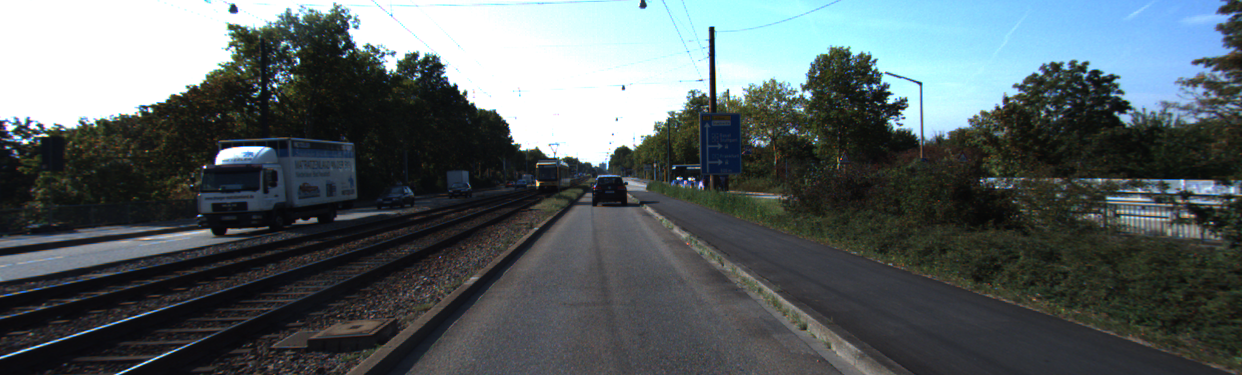

이미지: go_1.png
정답(label): go
VLM 선택: Go (정답 여부: True )

=== VLM의 reasoning ===
thought
1.  **Analyze the image:** The image shows a view from a vehicle on a multi-lane road with railway tracks running parallel to the road. It appears to be a rural or suburban setting with trees and vegetation on the right. There are several vehicles visible, including a white truck in the left lane and a dark car in the center lane moving away.

2.  **Identify potential collision risks:**
    *   **Immediate path:** The road ahead seems clear of immediate obstacles (other vehicles, pedestrians).
    *   **Railway tracks:** There are active railway tracks.
    *   **Other vehicles:** There is a truck in the left lane and a car ahead in the center lane. They appear to be moving normally.
    *   **Pedestrians/Cyclists:** No pedestrians or cyclists are clearly visible in the immediate path or near the road edge where a collision might occur.

3.  **Apply the driving assistant rules:**
    *   "if the vehic

In [ ]:
# 결과 하나를 골라 이미지와 reasoning을 출력합니다.
from IPython.display import display, Image as IPImage

# i 를 변경하여 데이터를 확인 할 수 있습니다
i = 0
display(IPImage(filename=image_paths[i]))
print("이미지:", rows[i]["image"])
print("정답(label):", rows[i]["label"])
print("VLM 선택:", rows[i]["answer"], "(정답 여부:", rows[i]["correct"], ")")
print()
print("=== VLM의 reasoning ===")
print(rows[i]["reasoning"])

### 3-6. 정확도 확인하고 CSV로 저장하기

이제 VLM이 얼마나 맞췄는지 정확도를 확인하고, 근거와 답을 표로 정리해 CSV 파일로 저장하겠습니다. 근거(reasoning)는 길어서 표에는 답만 보여 주고, 전체 근거는 CSV 파일 안에 담아 둘게요.

In [ ]:
import pandas as pd

df = pd.DataFrame(rows)
acc = df["correct"].mean() * 100
print(f"정확도: {acc:.1f}%  ({df['correct'].sum()}/{len(df)})")

# reasoning까지 모두 담아 CSV로 저장합니다.
df.to_csv("vlm_results.csv", index=False, encoding="utf-8-sig")
print("저장 완료: vlm_results.csv")

# 표에는 답만 간단히 보여 줍니다. (reasoning은 CSV에서 확인)
df[["image", "label", "answer", "correct"]]

정확도: 70.0%  (7/10)
저장 완료: vlm_results.csv


,image,label,answer,correct
0,go_1.png,go,Go,True
1,stop_4.png,stop,Go,False
2,go_4.png,go,Go,True
3,stop_3.png,stop,Stop,True
4,go_3.png,go,Go,True
5,stop_2.png,stop,Stop,True
6,stop_5.png,stop,Go,False
7,go_2.png,go,Go,True
8,stop_1.png,stop,Go,False
9,go_5.png,go,Go,True


### 3-7. 마무리하며

이번에는 VLM을 학습시키지 않고, 정성껏 짠 prompt 하나로 자율주행 상황을 판단하게 해 봤어요. 이미지를 주면 VLM이 신호등·사람·장애물을 살펴 근거를 말하고, go/stop 중 하나를 골라 <answer> 안에 답했죠. 그리고 그 답을 파일 이름의 정답과 비교해 정확도까지 재 봤습니다.

생각해 보면 지난 SAM3 과제와 좋은 대비를 이뤄요. 그때는 SAM3가 객체를 찾아 주긴 했지만, go인지 stop인지 가르는 판단만큼은 우리가 박스 feature를 모아 neural network를 따로 학습시켜야 비로소 얻을 수 있었죠. 반면 이번에는 그 학습 단계가 통째로 사라졌어요. VLM은 이미 장면을 이해하고 그 안에서 추론까지 할 줄 알기 때문에, 데이터를 모아 가중치를 맞추는 대신 "무엇을 보고 어떻게 판단해 달라"는 prompt 한 장으로 곧장 답을 얻을 수 있었습니다.

"가중치를 학습하는 대신 prompt를 작성한다" 이것이 바로 Software 3.0 방식의 문제 해결이에요. 더 나은 답이 필요하면 데이터를 다시 모으는 게 아니라 prompt 문장을 다듬고, 새로운 질문이 생기면 모델을 다시 학습하는 게 아니라 질문과 보기를 바꾸면 됩니다.

#### 직접 바꿔 보기

- build_action_prompt() 안의 주의사항 문장을 바꿔 보면서, VLM의 근거와 정확도가 어떻게 달라지는지 살펴보세요.
- VLM_MODEL을 다른 VLM으로 바꿔 같은 prompt에 대한 답을 비교해 보세요.
- FIXED_QUESTION이나 FIXED_CHOICES를 바꾸면 다른 객관식 질문으로도 같은 흐름을 그대로 쓸 수 있습니다.

Rubric
- 정확도 60% 이상을 달성하였다
  - 주어진 image-question data에서 일정 수준 이상의 task 성능을 달성하는 것을 목표로  한다. Software 3.0 관점에서는 코드를 직접 작성해 규칙을 고정하기보다, 모델의 입력과 사용 조건을 조정하여 원하는 동작을 끌어내는 기본 성능 기준을 확인한다.

- VLM의 답변에 대해서 원인을 분석하였다.
  - 모델이 왜 맞거나 틀렸는지, 이미지 정보 부족, 질문 해석 오류, 시각적 착각, prompt 해석 문제 등 원인을 분석하는 것을 목표로 한다.

- prompt 를 수정하여 정답율 70% 이상을 달성하였다.
  - 모델 자체를 재학습하지 않고 prompt를 수정하여 성능을 개선하는 경험을 목표로 한다. Software 3.0 관점에서 prompt가 일종의 프로그램 역할을 하므로, prompt 설계와 반복 실험을 통해 모델의 행동을 조정하고 task 성능을 높이는 과정을 경험하고 이를 정량적인 지표로 검증하는 것을 목표로 한다.

##Test 1 - modifying prompt


In [ ]:
# 질문·보기·판단 기준을 합쳐 모델에 넣을 prompt를 만듭니다.
def build_action_prompt(question=FIXED_QUESTION, choices=FIXED_CHOICES):
    labels = [chr(ord("A") + i) for i in range(len(choices))]
    option_lines = "\n".join(f"{label}. {choice}" for label, choice in zip(labels, choices))
    return (
        "You are a cautious driving assistant. Look carefully at the image taken from a vehicle.\n\n"
        "and decide whether the vehicle should keep moving (Go) or halt (Stop)\n"
        "Priorities to ensure safety:\n"
        "1. Start with checking wether there are pedestrians, cyclist, vehicles, traffic signals, and obstacles.\n"
        "2. Choose Stop if any obstacle or person or object may enter or block the vehicle's path\n"
        "3. Choose Stop if Go will increase possible of collision risk\n"
        "4. If the situation is uncertain, choose Stop for safety.\n"
        "5. Choose Go only if path ahead is clearly open and safe"


        "Question: " + question.strip() + "\n\n"
        "Options:\n" + option_lines + "\n\n"
        "First explain your reasoning in one or two sentences based on what you actually see, then give your final choice as the single option letter (" + ", ".join(labels) + ") inside <answer>...</answer>."
    )


I have tested with modifying the prompt to be more detail in several situations that prioritise safety when vehicle deciding to Go or to Stop. Changing the prompt have resulted in the same accuracy which is 80%. Still same result which are true for most Go situation yet still false during stop_4.png and stop_5.png.

차량이 Go 또는 Stop을 결정할 때 안전을 우선시할 수 있도록, 여러 상황에 대한 설명을 더 구체적으로 추가하여 prompt를 수정해 보았습니다. Prompt를 수정한 후에도 정확도는 80%로 동일하게 유지되었습니다. 대부분의 Go 상황에서는 여전히 올바르게 판단했지만, stop_4.png와 stop_5.png에서는 이전과 동일하게 잘못된 결과가 나왔습니다.

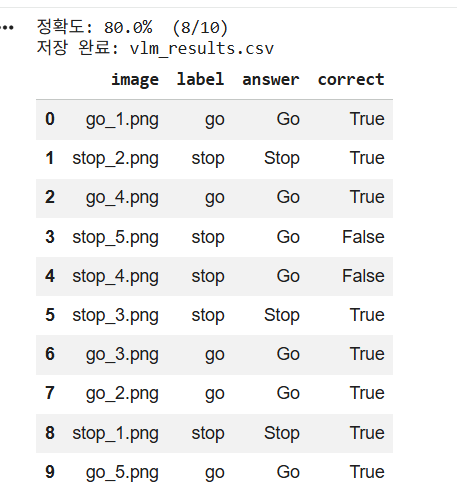

##Test 2 - use another VLM model

In [ ]:
# local VLM 모델과 processor를 로드합니다.
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

# 다른 VLM으로 바꾸려면 이 한 줄만 교체하세요.
VLM_MODEL = "Qwen/Qwen3-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(VLM_MODEL)
# device_map="auto"는 가능한 GPU/CPU 배치를 transformers가 자동으로 정하게 합니다.
model = AutoModelForImageTextToText.from_pretrained(
    VLM_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print("model loaded:", VLM_MODEL)

In this test, I use Qwen3-VL with the same prompt from the original model. Result shown that the accuracy decreased from 80% to 70% which same scenario where vehicle fail to stop during the needed-to-stop scenario. Also, this model has resulted in false for stop_1.png, stop_4.png and stop_5.png.

이번 테스트에서는 기존 모델에서 사용한 것과 동일한 prompt를 사용하여 Qwen3-VL 모델을 테스트했습니다. 그 결과 정확도가 80%에서 70%로 감소했습니다. 이전과 마찬가지로 차량이 정지해야 하는 상황에서 Stop으로 판단하지 못하는 오류가 나타났습니다. 특히 이 모델은 stop_1.png, stop_4.png, stop_5.png에서 잘못된 결과를 보였습니다.

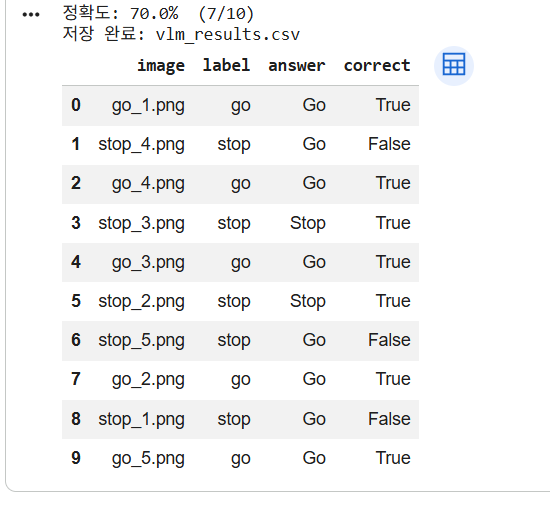